In [52]:
pip install optuna


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [53]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path

# Mount automatically (same folder)
BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "Maharashtra_AllCities_Hospital_Dataset.csv"
OUT_DIR = BASE_DIR / "outputs"
OUT_DIR.mkdir(exist_ok=True)

print("Working Directory:", BASE_DIR)
print("Dataset Found:", DATA_PATH.exists())

Working Directory: /Users/radhikapoonia/Downloads/srijan havkathon/files
Dataset Found: True


In [54]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Optional LSTM
HAS_TF = False
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    HAS_TF = True
    print("TensorFlow ✔")
except:
    print("TensorFlow ✗")

TensorFlow ✔


In [55]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (851, 47)


,Hospital_ID,District,City,State,City_Type,Hospital_Name,Reference_Period_AU595,Total_Beds,ICU_Beds,Non_ICU_Beds,...,Doctors_Orthopedic,Doctors_Pediatrician,Total_Doctors,Assurance_Available_Time,AU595_State_Rural_Hospitals,AU595_State_Urban_Hospitals,AU595_State_Total_Hospitals,AU595_State_Rural_Beds,AU595_State_Urban_Beds,AU595_State_Total_Beds
0,MH-1001,Mumbai City,Colaba,Maharashtra,Urban,City Health Care Colaba,31.08.2020,119,33,86,...,2,0,31,16 minutes,365,149,514,10950,22078,33028
1,MH-1002,Mumbai City,Colaba,Maharashtra,Urban,Central Hospital & ICU Colaba,31.08.2020,133,32,101,...,2,2,40,14 minutes,365,149,514,10950,22078,33028
2,MH-1003,Mumbai City,Colaba,Maharashtra,Urban,Sparsh Hospital Colaba,31.08.2020,137,52,85,...,0,1,48,13 minutes,365,149,514,10950,22078,33028
3,MH-1004,Mumbai City,Colaba,Maharashtra,Urban,Fortis Trauma Centre Colaba,31.08.2020,94,41,53,...,2,2,42,17 minutes,365,149,514,10950,22078,33028
4,MH-1005,Mumbai City,Fort,Maharashtra,Urban,Multispecialty Hospital Fort,31.08.2020,119,31,88,...,2,1,40,14 minutes,365,149,514,10950,22078,33028


In [56]:
TARGET_COL = "Total_Beds"

# Encode categorical
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Fill missing
df = df.fillna(df.median(numeric_only=True))

df.head()

,Hospital_ID,District,City,State,City_Type,Hospital_Name,Reference_Period_AU595,Total_Beds,ICU_Beds,Non_ICU_Beds,...,Doctors_Orthopedic,Doctors_Pediatrician,Total_Doctors,Assurance_Available_Time,AU595_State_Rural_Hospitals,AU595_State_Urban_Hospitals,AU595_State_Total_Hospitals,AU595_State_Rural_Beds,AU595_State_Urban_Beds,AU595_State_Total_Beds
0,0,16,63,0,2,103,0,119,33,86,...,2,0,31,6,365,149,514,10950,22078,33028
1,1,16,63,0,2,89,0,133,32,101,...,2,2,40,4,365,149,514,10950,22078,33028
2,2,16,63,0,2,649,0,137,52,85,...,0,1,48,3,365,149,514,10950,22078,33028
3,3,16,63,0,2,193,0,94,41,53,...,2,2,42,7,365,149,514,10950,22078,33028
4,4,16,86,0,2,441,0,119,31,88,...,2,1,40,4,365,149,514,10950,22078,33028


In [57]:
def generate_synthetic(df, ratio=0.4):
    n = int(len(df) * ratio)
    synth = df.sample(n, replace=True).copy()

    for col in df.select_dtypes(include=np.number).columns:
        noise = np.random.normal(0, df[col].std()*0.05, n)
        synth[col] = (synth[col] + noise).clip(df[col].min(), df[col].max())

    synth["is_synthetic"] = 1
    df["is_synthetic"] = 0

    return pd.concat([df, synth], ignore_index=True)

df = generate_synthetic(df)

# 🔥 ADD LAG FEATURES HERE
df["lag_1"] = df[TARGET_COL].shift(1)
df["lag_2"] = df[TARGET_COL].shift(2)
df["rolling_mean_3"] = df[TARGET_COL].rolling(3).mean()

# Remove NaN created by lag
df = df.dropna().reset_index(drop=True)

print("After synthetic + lag:", df.shape)

After synthetic + lag: (1189, 51)


In [58]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

feature_cols = X.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

split = int(len(X_scaled)*0.8)

X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y[:split], y[split:]

print(X_train.shape, X_test.shape)

(951, 50) (238, 50)


In [59]:
models = {}

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
models["RF"] = rf.predict(X_test)

hgb = HistGradientBoostingRegressor(
    max_iter=400,
    learning_rate=0.05,
    max_depth=8
)
hgb.fit(X_train, y_train)
models["HGB"] = hgb.predict(X_test)

print("Models trained:", models.keys())

Models trained: dict_keys(['RF', 'HGB'])


In [60]:


weights = {}

# calculate weights (inverse MAE)
for name in ["RF", "HGB"]:
    mae = mean_absolute_error(y_test, models[name])
    weights[name] = 1 / mae

# normalize weights
total = sum(weights.values())
weights = {k: v / total for k, v in weights.items()}

# build ensemble
ensemble = sum(weights[m] * models[m] for m in weights)

models["Ensemble"] = ensemble

print("Weights:", weights)

Weights: {'RF': 0.4928085309641523, 'HGB': 0.5071914690358477}


In [61]:
results = []

for name, preds in models.items():
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results.append([name, rmse, mae, r2])

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "MAE", "R2"])
results_df.sort_values("R2", ascending=False)

,Model,RMSE,MAE,R2
0,RF,2.054189,1.548725,0.994900
2,Ensemble,2.059733,1.509587,0.994872
1,HGB,2.173631,1.504806,0.994290


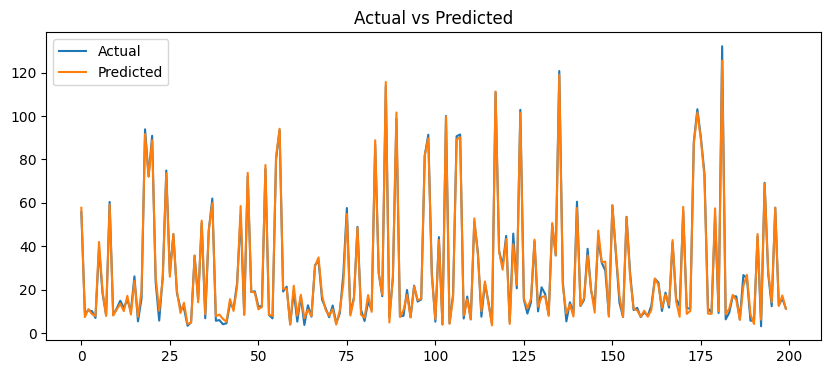

In [62]:
plt.figure(figsize=(10,4))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(ensemble[:200], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [63]:
def predict_new(input_row):
    x = scaler.transform([input_row])

    rf_pred = rf.predict(x)[0]
    hgb_pred = hgb.predict(x)[0]

    # weighted ensemble (same as training)
    pred = weights["RF"] * rf_pred + weights["HGB"] * hgb_pred

    return pred

In [64]:


# Save models
joblib.dump(rf, "rf.pkl")
joblib.dump(hgb, "hgb.pkl")
joblib.dump(scaler, "scaler.pkl")

# Save full pipeline (BEST)
joblib.dump({
    "rf": rf,
    "hgb": hgb,
    "scaler": scaler,
    "weights": weights,
    "features": feature_cols
}, "hospital_pipeline.pkl")

print("✅ All models + pipeline saved")

✅ All models + pipeline saved


In [65]:
data = joblib.load("hospital_pipeline.pkl")

rf = data["rf"]
hgb = data["hgb"]
scaler = data["scaler"]
weights = data["weights"]
feature_cols = data["features"]

In [67]:
test_inputs = [
    [1, 2, 0, 3, 1, 50, 120, 30, 45, 10, 0, 0, 0],  # small hospital
    [3, 5, 1, 6, 2, 150, 300, 100, 120, 40, 1, 1, 1],  # medium
    [5, 8, 1, 10, 3, 400, 800, 250, 300, 100, 1, 1, 1], # large
    [2, 1, 0, 2, 1, 20, 60, 10, 15, 5, 0, 0, 0],       # rural
]

In [71]:
print(feature_cols)
print(len(feature_cols))

['Hospital_ID', 'District', 'City', 'State', 'City_Type', 'Hospital_Name', 'Reference_Period_AU595', 'ICU_Beds', 'Non_ICU_Beds', 'Available_Beds', 'ICU_Rooms', 'General_Ward_Rooms', 'Private_Rooms', 'Semi_Private_Rooms', 'Emergency_Rooms', 'Operation_Theatres', 'Isolation_Rooms', 'Total_Rooms', 'Ventilators', 'Oxygen_Concentrators', 'ECG_Machines', 'Defibrillators', 'Pulse_Oximeters', 'CT_Scan', 'X_Ray_Machines', 'Ultrasound_Units', 'Blood_Analyzers', 'Patient_Monitors', 'Doctors_General_Physician', 'Doctors_Pulmonologist', 'Doctors_Cardiologist', 'Doctors_Intensivist', 'Doctors_Anesthesiologist', 'Doctors_Surgeon', 'Doctors_Radiologist', 'Doctors_Neurologist', 'Doctors_Orthopedic', 'Doctors_Pediatrician', 'Total_Doctors', 'Assurance_Available_Time', 'AU595_State_Rural_Hospitals', 'AU595_State_Urban_Hospitals', 'AU595_State_Total_Hospitals', 'AU595_State_Rural_Beds', 'AU595_State_Urban_Beds', 'AU595_State_Total_Beds', 'is_synthetic', 'lag_1', 'lag_2', 'rolling_mean_3']
50


In [72]:
sample = X.iloc[0].copy()

# Modify some values
sample = sample * 1.1  # simulate increase

pred = predict_new(sample.values)
print("Prediction:", pred)

Prediction: 132.56565506228745


In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

for name, preds in models.items():
    print(f"\n{name}")
    print("R2:", r2_score(y_test, preds))
    print("MAE:", mean_absolute_error(y_test, preds))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))


RF
R2: 0.9949000023629602
MAE: 1.5487247178163313
RMSE: 2.054189371488588

HGB
R2: 0.9942896777223881
MAE: 1.5048059749620784
RMSE: 2.17363090415714

Ensemble
R2: 0.9948724409009968
MAE: 1.5095869713055334
RMSE: 2.059732528605698
